In [7]:
# --! include root folders into PYTHONPATH

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

# --! import Python libraries

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

# --! import framework libraries

import example_mujoco
import util_data
import util_nn

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco'
result_path = '../../../results/mujoco'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_path}/walker2d_baseline_0', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([80, 918, 23])
read observations shape: torch.Size([80, 918, 17])
read actions shape: torch.Size([80, 918, 6])
shape of observations for training: torch.Size([80, 917, 17])
shape of next observations for training: torch.Size([80, 917, 17])
shape of actions for training: torch.Size([80, 917, 6])


### Training mixture of experts

In [3]:
model = example_mujoco.model_moe(obs_ndim, act_ndim, nexpert=4)
model.train()
example_mujoco.train_moe(model, dataloader, nepoch=500)

epoch 0, loss: 0.064728
epoch 20, loss: 0.020432
epoch 40, loss: 0.008698
epoch 60, loss: 0.003062
epoch 80, loss: -0.000143
epoch 100, loss: -0.002040
epoch 120, loss: -0.003350
epoch 140, loss: -0.004343
epoch 160, loss: -0.005029
epoch 180, loss: -0.005343
epoch 200, loss: -0.006232
epoch 220, loss: -0.006609
epoch 240, loss: -0.007008
epoch 260, loss: -0.007353
epoch 280, loss: -0.007477
epoch 300, loss: -0.007903
epoch 320, loss: -0.008076
epoch 340, loss: -0.008183
epoch 360, loss: -0.008485
epoch 380, loss: -0.008676
epoch 400, loss: -0.007941
epoch 420, loss: -0.008861
epoch 440, loss: -0.009099
epoch 460, loss: -0.009091
epoch 480, loss: -0.009140


### Testing model rollout

In [4]:
model.eval()
util_nn.freeze_module(model)

this_traj = 10

s0 = obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_moe(model, s0, act[this_traj])
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


### Plotting rollout results

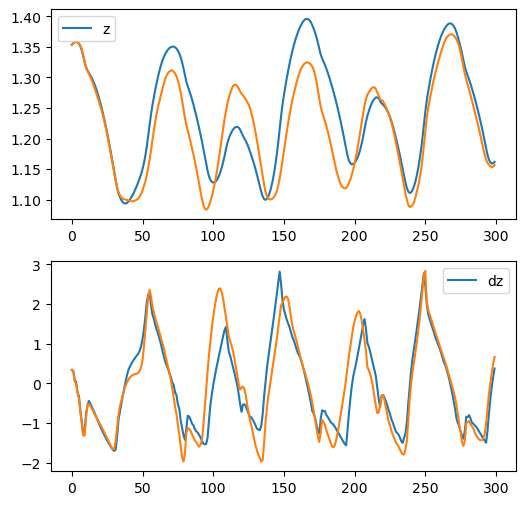

In [5]:
disp_end = 300
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    save_step = torch.arange(obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_moe_rollout', savedata, delim=' ')

In [8]:
traj_mse = []
with torch.no_grad():
    for j in range(obs.shape[0]): # trajectory
        mse = []
        for h in range(1, obs.shape[1]): # horizon
            s0 = obs[j, 0]
            cmp_rollout = example_mujoco.rollout_moe(model, s0, act[j, :h])

            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)
            mse.append(F.mse_loss(cmp_rollout, cmp_obs))
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)


tensor(0.0975)
tensor(0.1234)


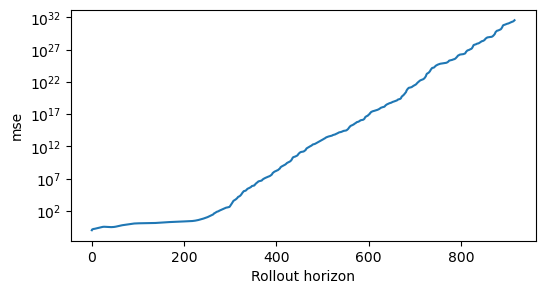

In [11]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = False
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_moe_mse', savedata, delim=' ')